## 1. Chargement des données et exploration initiale

**Objectif :**
Charger le jeu de données brut `train_loan.csv`, examiner sa structure, le nombre de lignes/colonnes ainsi que le type des variables.

**Actions :**
- Importation des bibliothèques principales (`pandas`, `numpy`, `matplotlib`, `seaborn`).
- Chargement du fichier depuis `data/raw/`.
- Affichage de l'aperçu (`head`), des dimensions (`shape`) et des types de données (`info`).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

In [ ]:
# Chargement du jeu de données
df = pd.read_csv('../data/raw/train_loan.csv')

In [4]:
# Étape 2 : Visualisation rapide de la structure
print("--- Dimensions de la base ---")
print(f"{df.shape[0]} lignes et {df.shape[1]} colonnes.\n")

# 1. Configurer Pandas pour ne pas couper les lignes à l'affichage
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
print("--- Les 5 premières lignes ---")
print(df.head())

--- Dimensions de la base ---
614 lignes et 13 colonnes.

--- Les 5 premières lignes ---
    Loan_ID Gender Married Dependents     Education Self_Employed  ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  Credit_History Property_Area Loan_Status
0  LP001002   Male      No          0      Graduate            No             5849                0.0         NaN             360.0             1.0         Urban           Y
1  LP001003   Male     Yes          1      Graduate            No             4583             1508.0       128.0             360.0             1.0         Rural           N
2  LP001005   Male     Yes          0      Graduate           Yes             3000                0.0        66.0             360.0             1.0         Urban           Y
3  LP001006   Male     Yes          0  Not Graduate            No             2583             2358.0       120.0             360.0             1.0         Urban           Y
4  LP001008   Male      No          0    

In [7]:
print("--- Informations générales ---")
df.info()

--- Informations générales ---
<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             601 non-null    str    
 2   Married            611 non-null    str    
 3   Dependents         599 non-null    str    
 4   Education          614 non-null    str    
 5   Self_Employed      582 non-null    str    
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    str    
 12  Loan_Status        614 non-null    str    
dtypes: float64(4), int64(1), str(8)
memory usage: 62.5 KB


## Étape 2 : Analyse des valeurs manquantes et nettoyage initial
**Objectif :**
Identifier la proportion de données manquantes dans chaque colonne et supprimer les identifiants uniques non pertinents pour la prédiction.

**Actions :**
- Suppression de la colonne `Loan_ID` (simple identifiant).
- Calcul du nombre et du pourcentage de valeurs manquantes par colonne.
- Visualisation graphique de la présence de valeurs manquantes.

--- Tableau des valeurs manquantes ---
                  Valeurs_Manquantes  Pourcentage (%)
Credit_History                    50             8.14
Self_Employed                     32             5.21
LoanAmount                        22             3.58
Dependents                        15             2.44
Loan_Amount_Term                  14             2.28
Gender                            13             2.12
Married                            3             0.49


C:\Users\MINA\AppData\Local\Temp\ipykernel_16048\3778502512.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_df[missing_df['Valeurs_Manquantes'] > 0].index,


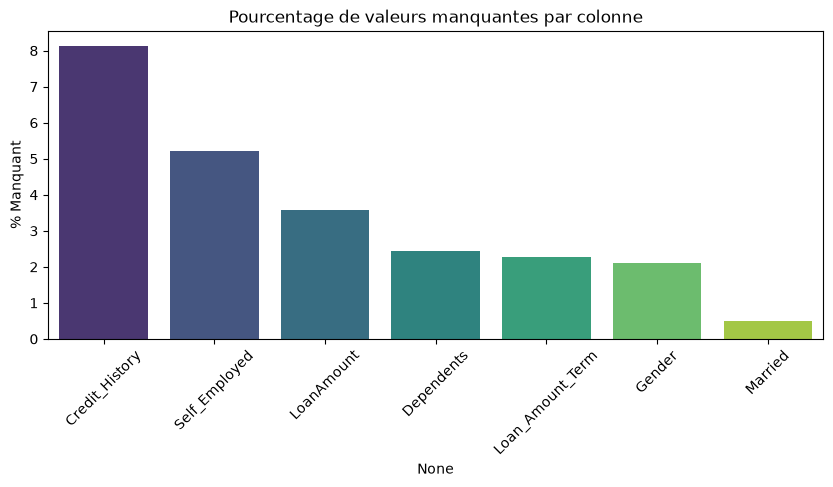

In [ ]:
                        # Suppression de Loan_ID
if 'Loan_ID' in df.columns:
    df = df.drop(columns=['Loan_ID'])

# Calcul du taux de valeurs manquantes
missing = df.isna().sum()
missing_percent = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Valeurs_Manquantes': missing,
    'Pourcentage (%)': missing_percent.round(2)
}).sort_values(by='Pourcentage (%)', ascending=False)

print("--- Tableau des valeurs manquantes ---")
print(missing_df[missing_df['Valeurs_Manquantes'] > 0])

# Graphique des valeurs manquantes
plt.figure(figsize=(10, 4))
sns.barplot(x=missing_df[missing_df['Valeurs_Manquantes'] > 0].index, 
            y=missing_df[missing_df['Valeurs_Manquantes'] > 0]['Pourcentage (%)'], 
            palette='viridis')
plt.title('Pourcentage de valeurs manquantes par colonne')
plt.xticks(rotation=45)
plt.ylabel('% Manquant')
plt.show()

## Étape 3 : Traitement des valeurs manquantes (Imputation)
**Objectif :**
Combler les données manquantes pour éviter de perdre des lignes lors de l'entraînement des modèles.

**Stratégie :**
- **Variables catégorielles (`Gender`, `Married`, `Dependents`, `Self_Employed`, `Credit_History`) :** Remplacement par la valeur la plus fréquente (le *mode*).
- **Variables numériques (`LoanAmount`, `Loan_Amount_Term`) :** Remplacement par la *médiane* pour résister aux valeurs aberrantes (outliers).

In [ ]:
# Imputation des variables catégorielles par le mode
cat_cols = ['Gender', 'Married', 'Dependents', 'Self_Employed', 'Credit_History']
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Imputation des variables numériques par la médiane
num_cols = ['LoanAmount', 'Loan_Amount_Term']
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

print("Vérification des valeurs manquantes après imputation :")
print(f"Total de valeurs manquantes restantes : {df.isna().sum().sum()}") # Pourquoi on a fait 2 sum ici ? Pourquoi on a choisi de faire une imputation ?

Vérification des valeurs manquantes après imputation :
Total de valeurs manquantes restantes : 0


C:\Users\MINA\AppData\Local\Temp\ipykernel_16048\4220346507.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Loan_Status', ax=axes[0, 0], palette='Set2')


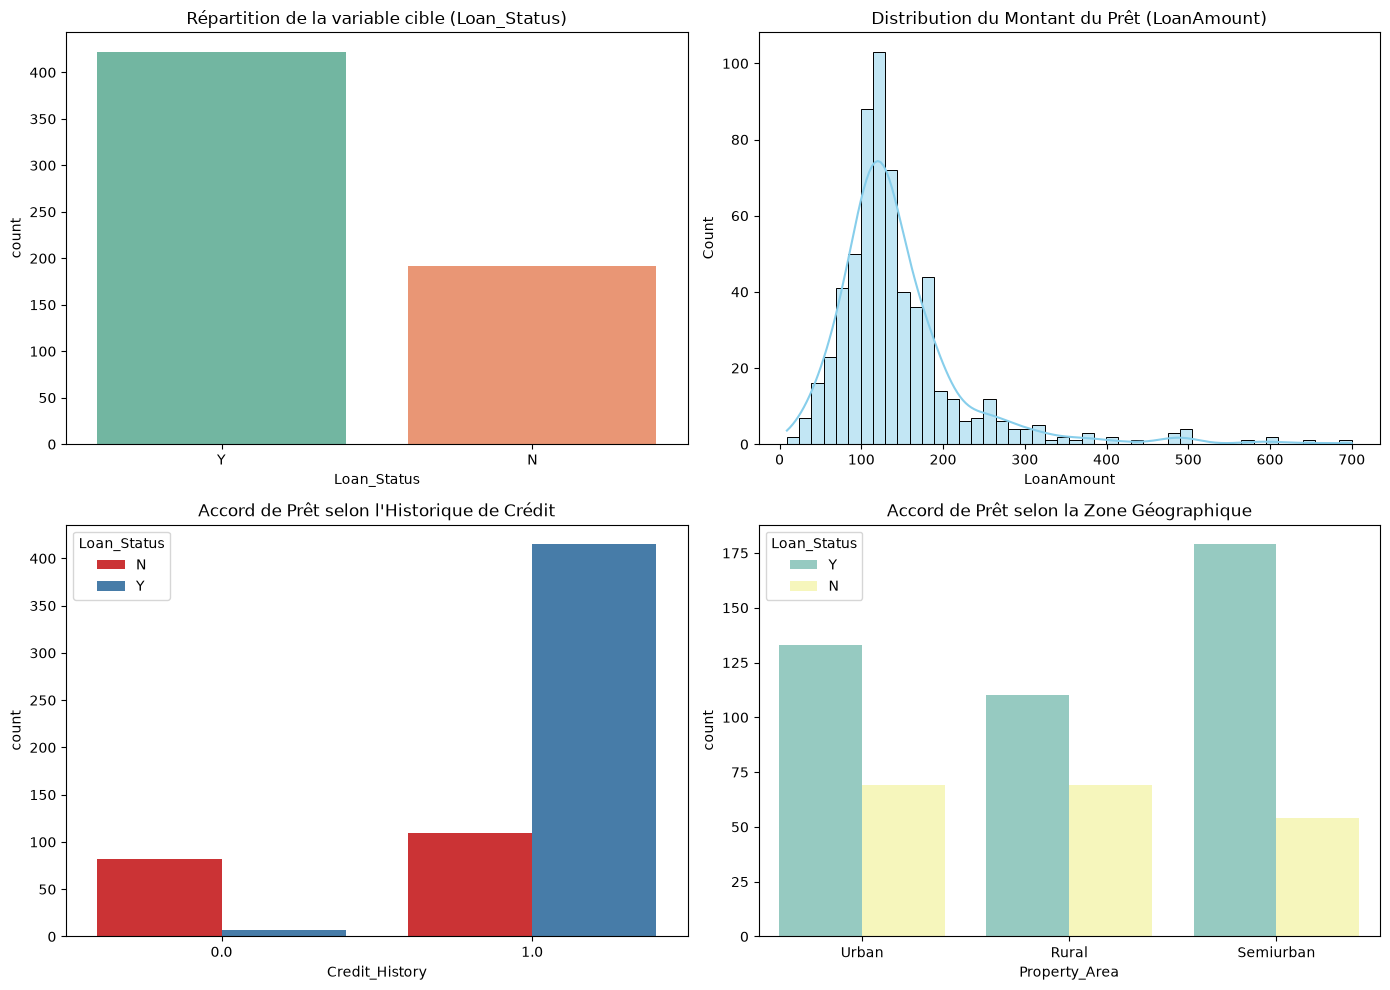

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Distribution de la cible Loan_Status
sns.countplot(data=df, x='Loan_Status', ax=axes[0, 0], palette='Set2')
axes[0, 0].set_title('Répartition de la variable cible (Loan_Status)')

# 2. Distribution de LoanAmount
sns.histplot(df['LoanAmount'], kde=True, ax=axes[0, 1], color='skyblue')
axes[0, 1].set_title('Distribution du Montant du Prêt (LoanAmount)')

# 3. Credit_History vs Loan_Status
sns.countplot(data=df, x='Credit_History', hue='Loan_Status', ax=axes[1, 0], palette='Set1')
axes[1, 0].set_title('Accord de Prêt selon l\'Historique de Crédit')

# 4. Property_Area vs Loan_Status
sns.countplot(data=df, x='Property_Area', hue='Loan_Status', ax=axes[1, 1], palette='Set3')
axes[1, 1].set_title('Accord de Prêt selon la Zone Géographique')

plt.tight_layout()
plt.show()

## Étape 5 : Encodage des variables textuelles

**Objectif :**
Transformer les variables textuelles en valeurs numériques exploitables par les algorithmes de Machine Learning.

**Méthode :**
- **Variable cible (`Loan_Status`) :** Mapping binaire (`Y` -> 1, `N` -> 0).
- **Variables catégorielles :** Conversion avec One-Hot Encoding (`pd.get_dummies`) en évitant le piège de multicolinéarité (`drop_first=True`).

In [11]:
# Encodage de la variable cible
df['Loan_Status'] = df['Loan_Status'].map({'Y': 1, 'N': 0})

# Application du One-Hot Encoding sur l'ensemble des colonnes catégorielles
df_encoded = pd.get_dummies(df, drop_first=True)

print("Forme du dataset après encodage :", df_encoded.shape)
df_encoded.head()

Forme du dataset après encodage : (614, 15)


,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Gender_Male,Married_Yes,Dependents_1,Dependents_2,Dependents_3+,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban
0,5849,0.0,128.0,360.0,1.0,1,True,False,False,False,False,False,False,False,True
1,4583,1508.0,128.0,360.0,1.0,0,True,True,True,False,False,False,False,False,False
2,3000,0.0,66.0,360.0,1.0,1,True,True,False,False,False,False,True,False,True
3,2583,2358.0,120.0,360.0,1.0,1,True,True,False,False,False,True,False,False,True
4,6000,0.0,141.0,360.0,1.0,1,True,False,False,False,False,False,False,False,True


## Étape 6 : Sauvegarde des données prétraitées
### 6. Sauvegarde du jeu de données nettoyé

**Objectif :**
Exporter le DataFrame final au format CSV dans le dossier `data/processed/` pour l'utiliser lors de l'entraînement des modèles (`train.ipynb`).

In [12]:
import os

# Création du dossier processed s'il n'existe pas
os.makedirs('../data/processed', exist_ok=True)

# Exportation en CSV
df_encoded.to_csv('../data/processed/cleaned_loan.csv', index=False)
print(" Fichier 'cleaned_loan.csv' sauvegardé avec succès dans 'data/processed/' !")

 Fichier 'cleaned_loan.csv' sauvegardé avec succès dans 'data/processed/' !


## Étape 7 : Feature Engineering (Création de nouvelles variables)

**Objectif :**
Créer de nouvelles variables explicatives à partir des données existantes pour aider le modèle à mieux capter la capacité de remboursement du demandeur.

**Nouvelles variables :**
- `Total_Income` : Somme du revenu du demandeur (`ApplicantIncome`) et du co-demandeur (`CoapplicantIncome`).
- `Income_to_Loan_Ratio` : Ratio entre le revenu total et le montant du prêt.
- `EMI` : Échéance mensuelle estimée du remboursement.

In [ ]:
# Recharge du dataset propre avant encodage si je souhaite créer les features au préalable
# 1. Revenu total du foyer
df['Total_Income'] = df['ApplicantIncome'] + df['CoapplicantIncome']

# 2. Ratio Revenu / Montant du prêt
df['Income_to_Loan_Ratio'] = df['Total_Income'] / df['LoanAmount']

# 3. Mensualité estimée (EMI)
df['EMI'] = df['LoanAmount'] / df['Loan_Amount_Term']

df[['Total_Income', 'Income_to_Loan_Ratio', 'EMI']].head()

,Total_Income,Income_to_Loan_Ratio,EMI
0,5849.0,45.695312,0.355556
1,6091.0,47.585938,0.355556
2,3000.0,45.454545,0.183333
3,4941.0,41.175000,0.333333
4,6000.0,42.553191,0.391667


## Étape 8 : Analyse des corrélations (Matrice de chaleur)

**Objectif :**
Identifier les variables fortement corrélées entre elles ou avec la cible `Loan_Status`.

**Actions :**
- Calcul de la matrice de corrélation de Pearson.
- Affichage d'une carte thermique (*heatmap*) pour visualiser les liaisons linéaires.

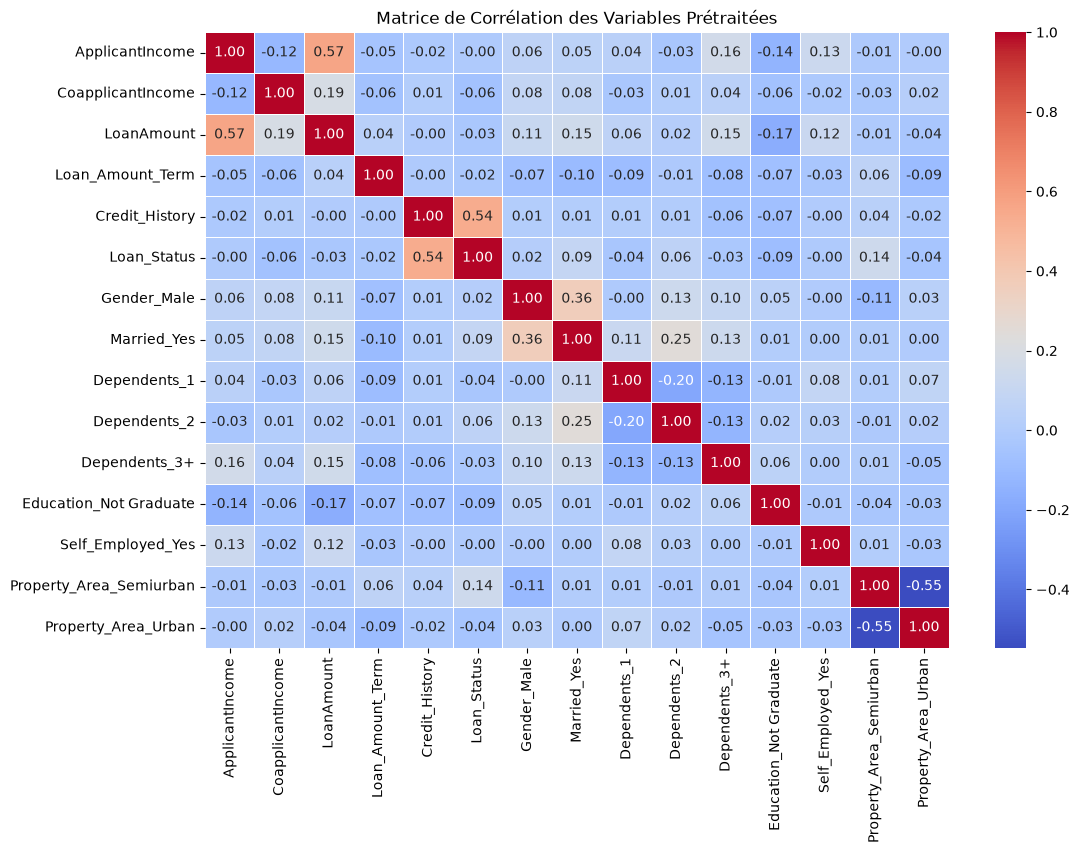

In [14]:
plt.figure(figsize=(12, 8))
correlation_matrix = df_encoded.corr()

# Affichage de la Heatmap
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Matrice de Corrélation des Variables Prétraitées')
plt.show()

## Étape 9 : Normalisation et Séparation des Données Cible / Features ($X$ et $y$)



**Objectif :**
Séparer les variables explicatives ($X$) de la variable cible ($y$) et mettre à l'échelle les caractéristiques numériques pour harmoniser leurs ordres de grandeur.

**Méthode :**
- Utilisation de `StandardScaler` de Scikit-Learn pour centrer et réduire les données.

In [15]:
from sklearn.preprocessing import StandardScaler

# 1. Séparation X et y
X = df_encoded.drop(columns=['Loan_Status'])
y = df_encoded['Loan_Status']

# 2. Normalisation / Standardisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Conversion en DataFrame pour conserver les noms de colonnes
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print("Forme des features X :", X_scaled.shape)
print("Forme de la cible y :", y.shape)
X_scaled.head()

Forme des features X : (614, 14)
Forme de la cible y : (614,)


,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Gender_Male,Married_Yes,Dependents_1,Dependents_2,Dependents_3+,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban
0,0.072991,-0.554487,-0.211241,0.273231,0.411733,0.472343,-1.372089,-0.446339,-0.443713,-0.300975,-0.528362,-0.392601,-0.782016,1.428147
1,-0.134412,-0.038732,-0.211241,0.273231,0.411733,0.472343,0.728816,2.240448,-0.443713,-0.300975,-0.528362,-0.392601,-0.782016,-0.700208
2,-0.393747,-0.554487,-0.948996,0.273231,0.411733,0.472343,0.728816,-0.446339,-0.443713,-0.300975,-0.528362,2.547117,-0.782016,1.428147
3,-0.462062,0.251980,-0.306435,0.273231,0.411733,0.472343,0.728816,-0.446339,-0.443713,-0.300975,1.892641,-0.392601,-0.782016,1.428147
4,0.097728,-0.554487,-0.056551,0.273231,0.411733,0.472343,-1.372089,-0.446339,-0.443713,-0.300975,-0.528362,-0.392601,-0.782016,1.428147


In [6]:
df.isna().sum() / len (df) 

Loan_ID              0.000000
Gender               0.021173
Married              0.004886
Dependents           0.024430
Education            0.000000
Self_Employed        0.052117
ApplicantIncome      0.000000
CoapplicantIncome    0.000000
LoanAmount           0.035831
Loan_Amount_Term     0.022801
Credit_History       0.081433
Property_Area        0.000000
Loan_Status          0.000000
dtype: float64